In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3554, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ats triumph,sector 104,4.45,6846.0,4,5,3+,27.0,Relatively New,7222.0,0,0,0,0,0,1,110
1,flat,dlf new town heights,sector 86,1.26,6114.0,3,3,3,5.0,Moderately Old,1747.0,0,1,0,0,1,1,113
2,flat,oriental valley chs,sector 9a,1.50,9091.0,4,3,3+,8.0,Relatively New,1833.0,0,0,0,0,0,0,8
3,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,2,2,3,19.0,Moderately Old,1410.0,0,0,0,0,0,1,63
4,flat,microtek greenburg,sector 86,1.45,9797.0,3,2,3,8.0,Relatively New,1480.0,0,0,0,0,0,2,72


In [6]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [7]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 104,4.45,4,5,3+,27.0,Relatively New,7222.0,0,0,0,0,0,1,110
1,flat,sector 86,1.26,3,3,3,5.0,Moderately Old,1747.0,0,1,0,0,1,1,113
2,flat,sector 9a,1.50,4,3,3+,8.0,Relatively New,1833.0,0,0,0,0,0,0,8
3,flat,sector 37d,0.75,2,2,3,19.0,Moderately Old,1410.0,0,0,0,0,0,1,63
4,flat,sector 86,1.45,3,2,3,8.0,Relatively New,1480.0,0,0,0,0,0,2,72


#### luxury score

<Axes: ylabel='luxury_score'>

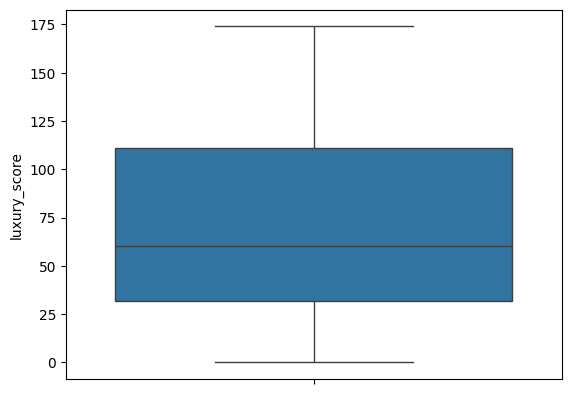

In [8]:
sns.boxplot(df['luxury_score'])

In [9]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [10]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [11]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 104,4.45,4,5,3+,27.0,Relatively New,7222.0,0,0,0,0,0,1,110,Medium
1,flat,sector 86,1.26,3,3,3,5.0,Moderately Old,1747.0,0,1,0,0,1,1,113,Medium
2,flat,sector 9a,1.50,4,3,3+,8.0,Relatively New,1833.0,0,0,0,0,0,0,8,Low
3,flat,sector 37d,0.75,2,2,3,19.0,Moderately Old,1410.0,0,0,0,0,0,1,63,Medium
4,flat,sector 86,1.45,3,2,3,8.0,Relatively New,1480.0,0,0,0,0,0,2,72,Medium


#### floorNum

<Axes: ylabel='floorNum'>

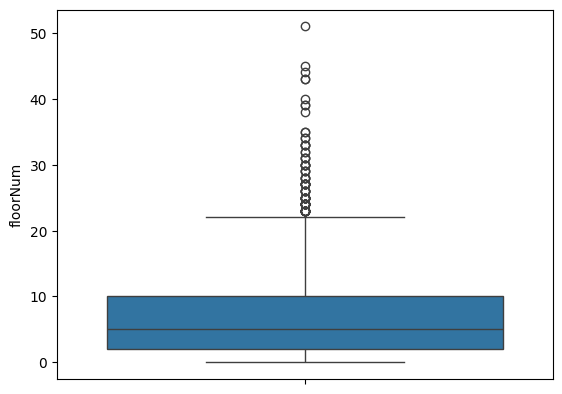

In [12]:
sns.boxplot(df['floorNum'])

In [13]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [14]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [15]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 104,4.45,4,5,3+,27.0,Relatively New,7222.0,0,0,0,0,0,1,110,Medium,High Floor
1,flat,sector 86,1.26,3,3,3,5.0,Moderately Old,1747.0,0,1,0,0,1,1,113,Medium,Mid Floor
2,flat,sector 9a,1.50,4,3,3+,8.0,Relatively New,1833.0,0,0,0,0,0,0,8,Low,Mid Floor
3,flat,sector 37d,0.75,2,2,3,19.0,Moderately Old,1410.0,0,0,0,0,0,1,63,Medium,High Floor
4,flat,sector 86,1.45,3,2,3,8.0,Relatively New,1480.0,0,0,0,0,0,2,72,Medium,Mid Floor


In [16]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [17]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 104,4.45,4,5,3+,Relatively New,7222.0,0,0,0,0,0,1,Medium,High Floor
1,flat,sector 86,1.26,3,3,3,Moderately Old,1747.0,0,1,0,0,1,1,Medium,Mid Floor
2,flat,sector 9a,1.50,4,3,3+,Relatively New,1833.0,0,0,0,0,0,0,Low,Mid Floor
3,flat,sector 37d,0.75,2,2,3,Moderately Old,1410.0,0,0,0,0,0,1,Medium,High Floor
4,flat,sector 86,1.45,3,2,3,Relatively New,1480.0,0,0,0,0,0,2,Medium,Mid Floor


In [18]:
final_df = train_df.drop(columns = ['study room' , 'pooja room' , 'others'])

In [19]:
final_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 104,4.45,4,5,3+,Relatively New,7222.0,0,0,1,Medium,High Floor
1,flat,sector 86,1.26,3,3,3,Moderately Old,1747.0,1,0,1,Medium,Mid Floor
2,flat,sector 9a,1.50,4,3,3+,Relatively New,1833.0,0,0,0,Low,Mid Floor
3,flat,sector 37d,0.75,2,2,3,Moderately Old,1410.0,0,0,1,Medium,High Floor
4,flat,sector 86,1.45,3,2,3,Relatively New,1480.0,0,0,2,Medium,Mid Floor


In [20]:
final_df.to_csv('gurgaon_properties_post_feature_selection_v2.csv' , index = False)

In [19]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [19]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,6.0,4,5,4.0,3.0,7222.0,0,0,0,0,0,1,2.0,0.0
1,0.0,98.0,3,3,3.0,0.0,1747.0,0,1,0,0,1,1,2.0,2.0
2,0.0,110.0,4,3,4.0,3.0,1833.0,0,0,0,0,0,0,1.0,2.0
3,0.0,44.0,2,2,3.0,0.0,1410.0,0,0,0,0,0,1,2.0,0.0
4,0.0,98.0,3,2,3.0,3.0,1480.0,0,0,0,0,0,2,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,0.0,6.0,3,4,4.0,3.0,2000.0,0,1,0,0,0,0,2.0,2.0
3550,0.0,78.0,3,3,1.0,3.0,1392.0,0,0,0,0,0,0,0.0,0.0
3551,0.0,39.0,2,2,2.0,3.0,724.0,0,0,0,0,0,2,1.0,1.0
3552,1.0,6.0,3,5,4.0,0.0,920.0,0,0,0,0,0,1,1.0,1.0


In [20]:
y_label

0       4.45
1       1.26
2       1.50
3       0.75
4       1.45
        ... 
3549    1.05
3550    1.40
3551    0.40
3552    1.95
3553    1.21
Name: price, Length: 3554, dtype: float64

#### Technique 1 - Correlation Analysis

<Axes: >

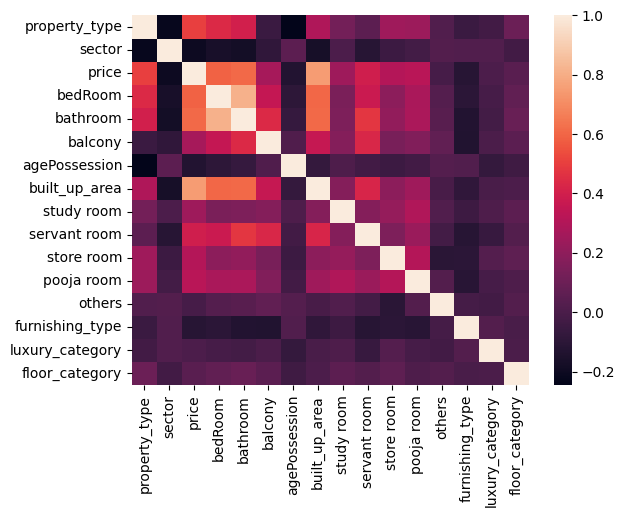

In [21]:
sns.heatmap(data_label_encoded.corr())

In [22]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})

In [23]:
fi_df1

,feature,corr_coeff
0,sector,-0.201845
1,price,1.000000
2,bedRoom,0.591289
3,bathroom,0.609777
4,balcony,0.269637
5,agePossession,-0.129866
6,built_up_area,0.748574
7,study room,0.242955
8,servant room,0.391930
9,store room,0.305677


#### Technique 2 - Random Forest Feature Importance

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

In [25]:
fi_df2

,feature,rf_importance
6,built_up_area,0.646066
1,sector,0.104842
0,property_type,0.102406
2,bedRoom,0.028855
3,bathroom,0.024501
8,servant room,0.019060
5,agePossession,0.014644
4,balcony,0.012865
12,furnishing_type,0.009810
7,study room,0.008599


#### Technique 3 - Gradient Boosting Feature importances

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

KeyboardInterrupt: 

#### Technique 4 - Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

#### Technique 5 - RFE

In [ ]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df5 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

In [ ]:
fi_df5

In [ ]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').set_index('feature')

In [ ]:
final_fi_df

In [ ]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [ ]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

In [ ]:
# to drop pooja room, study room, others
X_label

In [ ]:

# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [ ]:
scores.mean()

In [ ]:

export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [ ]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [ ]:
export_df